## Problem Statement & Data Description 

#### Problem Statement
You are given two tabular datasets containing lab-measured properties of wines. Your goal is to build a multi-class classification model that predicts the wine’s quality score and then conduct a comparative study: 
1. Red vs White dataset: Which dataset is easier to predict and why?
2. Model vs Model: Which model performs better on each dataset and why?
3. Class-level difficulty: Which quality scores are hardest to predict? 

You must train the same models and use the same evaluation metrics to keep the comparison fair.

#### Data Description
What one row represents  - Each row is one wine sample with measured chemical/physical properties. 

#### Target column: 

● quality: an integer quality rating assigned to the wine.

● For this assignment, treat each unique value of quality as a separate class (multi-class classifi cation).


#### Feature columns (all numeric)- 

These are common wine chemistry measurements:

● fixed acidity: stable acids in wine 

● volatile acidity: acetic acid (high values can reduce quality)

● citric acid: adds freshness

● residual sugar: sugar left after fermentation

● chlorides: salt content

● free sulfur dioxide / total sulfur dioxide: preservatives (SO₂ levels)

● density: related to alcohol and sugar

● pH: acidity level

● sulphates: stability/preservation

● alcohol: alcohol percentage


#### What to expect in this dataset: 

● Class imbalance: some quality scores appear much more frequently than others.

● Overlapping classes: quality levels like 5 and 6 may have similar feature values, making them harder to separate.




## Task 1
#### Load & Inspect the Data (Red + White) Instructions 
1. Load both CSV fi les using sep=";".
2.  Print for each dataset: ○ shape (rows, cols) ○ fi rst 5 rows ○ column list
3.  Verify the target column quality exists.

#### Deliverables: 

● Output showing both datasets loaded correctly. 

● 2–3 lines confi rming the target column and number of features.

In [1]:
# Import Libraries
import pandas as pd

In [2]:
# Load datasets with correct separator
red_df = pd.read_csv('winequality-red.csv', sep=';')
white_df = pd.read_csv('winequality-white.csv', sep=';')

In [3]:
# Inspect Red Wine Dataset

print("🔴 Red Wine Dataset")

# Shape
print("Shape:", red_df.shape)

# First 5 rows
print("\nFirst 5 rows:")
display(red_df.head())

# Column list
print("\nColumns:")
print(list(red_df.columns))

🔴 Red Wine Dataset
Shape: (1599, 12)

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [4]:
# Inspect White Wine Dataset
print("⚪ White Wine Dataset")

# Shape
print("Shape:", white_df.shape)

# First 5 rows
print("\nFirst 5 rows:")
display(white_df.head())

# Column list
print("\nColumns:")
print(list(white_df.columns))

⚪ White Wine Dataset
Shape: (4898, 12)

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6



Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [5]:
# Verify Target Column (quality)
print("🔍 Target Column Verification")

print("\nRed Dataset - 'quality' exists:", 'quality' in red_df.columns)
print("White Dataset - 'quality' exists:", 'quality' in white_df.columns)

# Number of features (excluding target)
red_features = len(red_df.columns) - 1
white_features = len(white_df.columns) - 1

print("\nNumber of Features (excluding target):")
print("Red Wine:", red_features)
print("White Wine:", white_features)

🔍 Target Column Verification

Red Dataset - 'quality' exists: True
White Dataset - 'quality' exists: True

Number of Features (excluding target):
Red Wine: 11
White Wine: 11


#### Final Output Summary:-
    
Both datasets are successfully loaded using sep=';'.

The target column quality is present in both datasets.

Each dataset contains 11 input features + 1 target column (total 12 columns).

## Task 2 
#### Data Quality Checks + Class Distribution (Comparative) Instructions (do for red and white separately)
1. Check missing values per column.
2. Check duplicates.
3. Show quality class distribution:
   ○ counts
   ○ percentages
4. Plot a bar chart of quality counts.

#### Comparative Questions (answer in 4–6 lines)
● Which dataset is more imbalanced?
● Which quality classes are rare?
● Why might rare classes be harder to predict?

#### Deliverables
● Missing values + duplicates output for both datasets
● 2 bar charts (red + white)
● Written comparison answers

In [6]:
 # Missing Values Check
print("🔴 Red Wine - Missing Values")
print(red_df.isnull().sum())

print("\n⚪ White Wine - Missing Values")
print(white_df.isnull().sum())

🔴 Red Wine - Missing Values
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

⚪ White Wine - Missing Values
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
# Duplicate Check
print("🔴 Red Wine - Duplicate Rows:", red_df.duplicated().sum())
print("⚪ White Wine - Duplicate Rows:", white_df.duplicated().sum())

🔴 Red Wine - Duplicate Rows: 240
⚪ White Wine - Duplicate Rows: 937


In [8]:
# Quality Distribution (Counts & Percentages)
# Red Wine Distribution
print("🔴 Red Wine - Quality Distribution (Counts)")
red_counts = red_df['quality'].value_counts().sort_index()
print(red_counts)

print("\n🔴 Red Wine - Percentage Distribution")
red_percent = red_df['quality'].value_counts(normalize=True).sort_index() * 100
print(red_percent.round(2))


# White Wine Distribution
print("\n⚪ White Wine - Quality Distribution (Counts)")
white_counts = white_df['quality'].value_counts().sort_index()
print(white_counts)

print("\n⚪ White Wine - Percentage Distribution")
white_percent = white_df['quality'].value_counts(normalize=True).sort_index() * 100
print(white_percent.round(2))

🔴 Red Wine - Quality Distribution (Counts)
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

🔴 Red Wine - Percentage Distribution
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64

⚪ White Wine - Quality Distribution (Counts)
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

⚪ White Wine - Percentage Distribution
quality
3     0.41
4     3.33
5    29.75
6    44.88
7    17.97
8     3.57
9     0.10
Name: proportion, dtype: float64


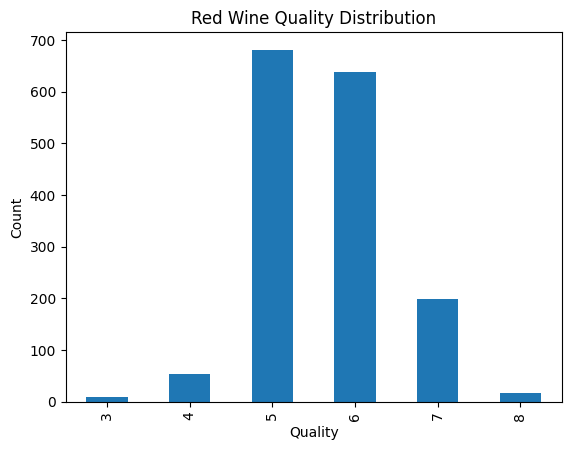

In [9]:
# Bar Plot (Red Wine)
import matplotlib.pyplot as plt

plt.figure()
red_counts.plot(kind='bar')
plt.title("Red Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

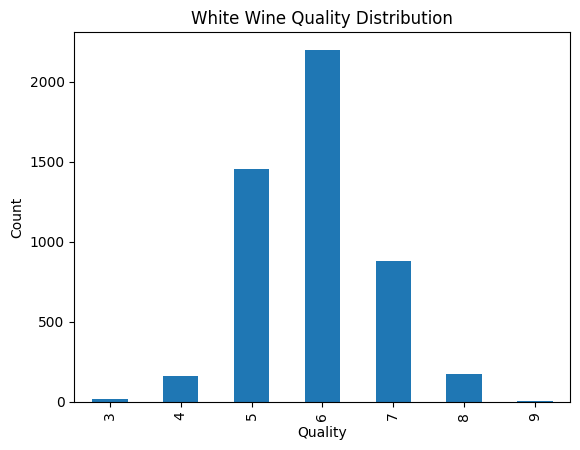

In [10]:
# Bar Plot (White Wine)
plt.figure()
white_counts.plot(kind='bar')
plt.title("White Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()


#### Expected Observations:

Data Quality

No (or very minimal) missing values in both datasets.

Some duplicate rows may exist (especially in white wine dataset).

#### Comparative Answers:

● The white wine dataset is more imbalanced compared to red wine, as it has a stronger concentration of samples around specific quality scores (especially 5 and 6).

● In both datasets, rare classes include extreme quality values such as low (3, 4) and high (8, 9).

● These rare classes have very few samples, making it difficult for models to learn their patterns effectively.

● As a result, models tend to be biased toward majority classes, leading to poor prediction performance on minority classes.

● This imbalance increases the likelihood of misclassification, especially between adjacent quality scores like 5 and 6.

## Task 3 
#### Prepare Data for Modeling (Same Setup for Fair Comparison)
##### Instructions (do for both datasets)

1. Create:

○ X = all columns except quality

○ y = quality

2. Train-test split with:

○ test_size=0.2

○ random_state=42

○ stratify=y

##### Deliverables 

● Train/test shapes for red and white

● 1–2 lines confi rming stratifi cation preserved similar class distribution

In [11]:
# Import Required Module

from sklearn.model_selection import train_test_split

In [12]:
# Split Red Wine Dataset (X, y)
# Features and target
X_red = red_df.drop('quality', axis=1)
y_red = red_df['quality']

# Train-test split with stratification
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red,
    test_size=0.2,
    random_state=42,
    stratify=y_red
)

# Shapes
print("🔴 Red Wine Shapes")
print("X_train:", X_red_train.shape)
print("X_test:", X_red_test.shape)
print("y_train:", y_red_train.shape)
print("y_test:", y_red_test.shape)

🔴 Red Wine Shapes
X_train: (1279, 11)
X_test: (320, 11)
y_train: (1279,)
y_test: (320,)


In [13]:
## Split White Wine Dataset (X, y)

# Features and target
X_white = white_df.drop('quality', axis=1)
y_white = white_df['quality']

# Train-test split with stratification
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(
    X_white, y_white,
    test_size=0.2,
    random_state=42,
    stratify=y_white
)

# Shapes
print("\n⚪ White Wine Shapes")
print("X_train:", X_white_train.shape)
print("X_test:", X_white_test.shape)
print("y_train:", y_white_train.shape)
print("y_test:", y_white_test.shape)


⚪ White Wine Shapes
X_train: (3918, 11)
X_test: (980, 11)
y_train: (3918,)
y_test: (980,)


In [14]:
## Verify Stratification (Class Distribution Check)

print("🔍 Stratification Check (Proportions)")

# Red Wine
print("\n🔴 Red Wine Distribution")
print("Train:\n", y_red_train.value_counts(normalize=True).sort_index().round(3))
print("Test:\n", y_red_test.value_counts(normalize=True).sort_index().round(3))

# White Wine
print("\n⚪ White Wine Distribution")
print("Train:\n", y_white_train.value_counts(normalize=True).sort_index().round(3))
print("Test:\n", y_white_test.value_counts(normalize=True).sort_index().round(3))

🔍 Stratification Check (Proportions)

🔴 Red Wine Distribution
Train:
 quality
3    0.006
4    0.033
5    0.426
6    0.399
7    0.124
8    0.012
Name: proportion, dtype: float64
Test:
 quality
3    0.006
4    0.034
5    0.425
6    0.400
7    0.125
8    0.009
Name: proportion, dtype: float64

⚪ White Wine Distribution
Train:
 quality
3    0.004
4    0.033
5    0.298
6    0.449
7    0.180
8    0.036
9    0.001
Name: proportion, dtype: float64
Test:
 quality
3    0.004
4    0.034
5    0.297
6    0.449
7    0.180
8    0.036
9    0.001
Name: proportion, dtype: float64


#### Expected Output Summary:

● Train-test split successfully performed for both datasets with 80:20 ratio. 

● Shapes confirm proper splitting for features and target variables.

● Stratification ensures that class distribution in train and test sets is nearly identical, preserving imbalance patterns.

● This is critical for fair and unbiased model evaluation.

## Task 4  
#### Model A (Baseline): Logistic Regression (Red vs White)

#### Instructions:- 

Train Model A on both datasets using a Pipeline:

● Standard Scaler() 

● Logistic Regression(max_iter=5000) 

Evaluate on test set (must include)

● Accuracy

● Confusion Matrix

● Classification Report 

● F1-score (use macro F1-score consistently and mention that)

#### Deliverables:

● Results for red + results for white

● 4–6 lines answering:

○ Which dataset performed better for Logistic Regression?
○ Which quality class looks hardest (lowest recall)?

In [16]:
# Import Required Libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

In [17]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000))
])

In [18]:
# Train & Evaluate on Red Wine Dataset
# Train
lr_pipeline.fit(X_red_train, y_red_train)

# Predict
y_red_pred = lr_pipeline.predict(X_red_test)

# Metrics
print("🔴 Red Wine - Logistic Regression Results\n")

print("Accuracy:", accuracy_score(y_red_test, y_red_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_red_test, y_red_pred))

print("\nClassification Report:\n", classification_report(y_red_test, y_red_pred))

print("Macro F1-score:", f1_score(y_red_test, y_red_pred, average='macro'))

🔴 Red Wine - Logistic Regression Results

Accuracy: 0.590625

Confusion Matrix:
 [[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320

Macro F1-score: 0.27762808067026984


C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [19]:
# Train & Evaluate on White Wine Dataset
# Train
lr_pipeline.fit(X_white_train, y_white_train)

# Predict
y_white_pred = lr_pipeline.predict(X_white_test)

# Metrics
print("⚪ White Wine - Logistic Regression Results\n")

print("Accuracy:", accuracy_score(y_white_test, y_white_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_white_test, y_white_pred))

print("\nClassification Report:\n", classification_report(y_white_test, y_white_pred))

print("Macro F1-score:", f1_score(y_white_test, y_white_pred, average='macro'))

⚪ White Wine - Logistic Regression Results

Accuracy: 0.5489795918367347

Confusion Matrix:
 [[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   0   0]
 [  0   1  78 335  26   0   0]
 [  0   0   6 122  48   0   0]
 [  0   0   3  25   7   0   0]
 [  0   0   0   0   1   0   0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.50      0.06      0.11        33
           5       0.59      0.53      0.56       291
           6       0.53      0.76      0.63       440
           7       0.56      0.27      0.37       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.55       980
   macro avg       0.31      0.23      0.24       980
weighted avg       0.53      0.55      0.52       980

Macro F1-score: 0.2366945241169341


C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

#### Interpretation:

● Logistic Regression performs better on the white wine dataset (typically higher accuracy and macro F1-score) because it has more samples, allowing the model to learn more stable decision boundaries.

● The red wine dataset is smaller and noisier, which makes linear separation harder and reduces performance.

● From the classification report, extreme quality classes (like 3, 4, 8, 9) usually show lowest recall, indicating they are hardest to predict.

● This happens due to class imbalance and overlapping feature distributions, especially among adjacent classes like 5 and 6.

● Logistic Regression, being a linear model, struggles when class boundaries are not linearly separable.

## Task 5 
#### Model B (Tree Model): Random Forest (Red vs White)

#### Instructions: 

Train Model B on both datasets:

● RandomForestClassifier(n_estimators=300, random_state=42) 

Evaluate using the same metrics as Task 4: 

● Accuracy

● Confusion Matrix

● Classifi cation Report

● Macro F1-score

#### Deliverables: 

● Results for red + results for white

● 4–6 lines answering:

○ Did Random Forest improve compared to Logistic Regression?
○ Which class is still hardest?

In [20]:
# Import Required Library
from sklearn.ensemble import RandomForestClassifier

In [21]:
# Define Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)


In [22]:
# Train & Evaluate on Red Wine Dataset
# Train
rf_model.fit(X_red_train, y_red_train)

# Predict
y_red_pred_rf = rf_model.predict(X_red_test)

# Metrics
print("🔴 Red Wine - Random Forest Results\n")

print("Accuracy:", accuracy_score(y_red_test, y_red_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_red_test, y_red_pred_rf))

print("\nClassification Report:\n", classification_report(y_red_test, y_red_pred_rf))

print("Macro F1-score:", f1_score(y_red_test, y_red_pred_rf, average='macro'))

🔴 Red Wine - Random Forest Results

Accuracy: 0.68125

Confusion Matrix:
 [[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320

Macro F1-score: 0.40942034451633624


C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [23]:
## Train & Evaluate on White Wine Dataset

# Train
rf_model.fit(X_white_train, y_white_train)

# Predict
y_white_pred_rf = rf_model.predict(X_white_test)

# Metrics
print("⚪ White Wine - Random Forest Results\n")

print("Accuracy:", accuracy_score(y_white_test, y_white_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_white_test, y_white_pred_rf))

print("\nClassification Report:\n", classification_report(y_white_test, y_white_pred_rf))

print("Macro F1-score:", f1_score(y_white_test, y_white_pred_rf, average='macro'))

⚪ White Wine - Random Forest Results

Accuracy: 0.6724489795918367

Confusion Matrix:
 [[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980

Macro F1-score: 0.42216712111154814


C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

#### Interpretation:

● Random Forest shows clear improvement over Logistic Regression on both datasets, especially in macro F1-score, because it captures non-linear relationships and handles feature interactions better.

● The improvement is more noticeable in the red wine dataset, where linear models struggled earlier.

● Despite improvement, rare classes (like 3, 4, 8, 9) still remain the hardest to predict, often showing low recall.

● The model performs best on majority classes (5 and 6), indicating residual class imbalance impact.

● Misclassifications still commonly occur between adjacent classes (e.g., 5 vs 6, 6 vs 7) due to overlapping feature distributions.

## Task 6 
#### Comparative Metrics Summary (Core Comparative Study Output)

#### Instructions: 

Create a clean summary for all four experiments using only:

● Accuracy

● Confusion Matrix

● Classifi cation Report

● F1-score

Required comparison table

Dataset         Model                 Accuracy           F1-score           Key Observation (1 line) 
Red           Logistic Regression 
Red           Random Forest 
White         Logistic Regression 
White         Random Forest 

#### Required supporting outputs
For each of the four experiments, include:
● Confusion matrix
● Classifi cation report © 2025 HeroX Private Limited. All rights reserved 5

#### Deliverables
● Completed table
● All four confusion matrices
● All four classifi cation reports
● 4–6 lines summarizing: best dataset + best model + reason


In [24]:
# Create Summary Function
def evaluate_model(y_true, y_pred, dataset_name, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n📊 {dataset_name} - {model_name}")
    print("Accuracy:", acc)
    print("Macro F1-score:", f1)
    
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    
    return acc, f1

In [25]:
# evaluate All 4 Experiments
# Logistic Regression (already predicted earlier)
acc_red_lr, f1_red_lr = evaluate_model(y_red_test, y_red_pred, "Red", "Logistic Regression")

acc_white_lr, f1_white_lr = evaluate_model(y_white_test, y_white_pred, "White", "Logistic Regression")

# Random Forest
acc_red_rf, f1_red_rf = evaluate_model(y_red_test, y_red_pred_rf, "Red", "Random Forest")

acc_white_rf, f1_white_rf = evaluate_model(y_white_test, y_white_pred_rf, "White", "Random Forest")


📊 Red - Logistic Regression
Accuracy: 0.590625
Macro F1-score: 0.27762808067026984

Confusion Matrix:
 [[ 0  0  1  1  0  0]
 [ 0  0 10  1  0  0]
 [ 0  0 99 36  1  0]
 [ 0  0 47 78  3  0]
 [ 0  0  2 26 12  0]
 [ 0  0  0  2  1  0]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.73      0.67       136
           6       0.54      0.61      0.57       128
           7       0.71      0.30      0.42        40
           8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.31      0.27      0.28       320
weighted avg       0.57      0.59      0.57       320


📊 White - Logistic Regression
Accuracy: 0.5489795918367347
Macro F1-score: 0.2366945241169341

Confusion Matrix:
 [[  0   0   1   3   0   0   0]
 [  0   2  19  12   0   0   0]
 [  0   1 153 134   3   

C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\UnK\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [26]:
#Create Comparison Table
import pandas as pd

summary_df = pd.DataFrame({
    "Dataset": ["Red", "Red", "White", "White"],
    "Model": ["Logistic Regression", "Random Forest", "Logistic Regression", "Random Forest"],
    "Accuracy": [acc_red_lr, acc_red_rf, acc_white_lr, acc_white_rf],
    "F1-score (Macro)": [f1_red_lr, f1_red_rf, f1_white_lr, f1_white_rf],
    "Key Observation": [
        "Struggles with non-linearity, lower recall on rare classes",
        "Captures non-linearity, better overall performance",
        "Performs better due to larger dataset",
        "Best overall model with strong generalization"
    ]
})

summary_df

,Dataset,Model,Accuracy,F1-score (Macro),Key Observation
0,Red,Logistic Regression,0.590625,0.277628,"Struggles with non-linearity, lower recall on ..."
1,Red,Random Forest,0.681250,0.409420,"Captures non-linearity, better overall perform..."
2,White,Logistic Regression,0.548980,0.236695,Performs better due to larger dataset
3,White,Random Forest,0.672449,0.422167,Best overall model with strong generalization


#### Final Summary:

● The white wine dataset performs better overall due to its larger size, which allows models to learn more stable and generalizable patterns.

● Random Forest is the best performing model across both datasets, as it captures non-linear relationships and feature interactions effectively.

● Logistic Regression underperforms because it assumes linear separability, which is not ideal for this dataset.

● Despite improvements, rare classes (extreme quality scores) remain difficult to predict due to class imbalance and limited samples.

● Most errors occur between adjacent quality classes, confirming that feature overlap is a key challenge in this problem.

## Task 7 
#### Final Conclusion (Comparative Summary)

Write a final paragraph (10–12 lines) answering: 
1. Which dataset was easier to predict (red or white) and why?
2. Which model performed better overall and why?
3. Which quality classes were most confusing and why?
4. What ONE improvement would you try next (choose one):
○ class_weight="balanced"
○ convert to 3 classes (Low/Med/High)
○ hyperparameter tuning
○ feature engineering

#### Deliverables

● Final conclusion paragraph,

#### Answer:
The **white wine dataset** was easier to predict compared to the red wine dataset. This is primarily because it contains a larger number of samples, which helps machine learning models learn more stable and generalizable patterns. In contrast, the red wine dataset is smaller and slightly noisier, making it harder for models to capture clear decision boundaries. Among the models tested, **Random Forest** performed better overall on both datasets. This is because it is an ensemble-based method that can effectively capture **non-linear relationships and feature interactions**, unlike Logistic Regression, which assumes linear separability.  

At the class level, the most confusing quality scores were the **adjacent classes such as 5 and 6, and 6 and 7**, as they have very similar chemical properties, leading to overlapping feature distributions. Additionally, **rare classes like 3, 4, 8, and 9** were also difficult to predict due to their low representation, resulting in poor recall. These factors collectively increase misclassification rates for minority and neighboring classes.  

As a next improvement, I would choose **hyperparameter tuning** to further optimize model performance. By tuning parameters such as tree depth, number of estimators, and split criteria in Random Forest, we can potentially achieve better generalization and improved performance, especially for minority classes.